# Classificação de nuvens com Visão computacional

- [Setup](#setup)
  - [Importando pacotes](#importando-pacotes)
  - [Criando device](#criando-device)
  - [Definindo funções](#definindo-funções)
  - [Importando dados](#importando-dados)
- [Criando modelo](#criando-modelo)
  - [Feature extraction](#feature-extraction)
  - [Global Pooling](#global-pooling)
  - [Classification block](#classification-block)
- [Treinando e avaliando modelos](#treinando-e-avaliando-modelos)
  - [Processos de transformação para datasets com Data Augmentation](#processos-de-transformação-para-dataset-com-data-augmentation)
  - [Discutindo performance](#discutindo-performance)
  - [Modelo simples](#modelo-simples)
    - [Fazendo previsões](#fazendo-previsões)
  - [Modelo com Data Augmentation](#modelo-com-data-augmentation)
    - [Fazendo previsões](#fazendo-previsões)
- [Transfer Learning](#transfer-learning)
  - [Performance na classificação de nuvens](#performance-na-classificação-de-nuvens)
  - [Fazendo previsões](#fazendo-previsões)

## Enunciado

1. Kaggle sugerida para o período – Classificação de Nuvens

2. Fazer uma rede convolucional Multiclasse do zero em Pytorch e Torchvision e avaliar no dataset;

3. Pegar uma rede pré treinada (Transfer Learning) e avaliar no dataset, comparando diferenças com o método anterior;

4. Avaliar métodos de regularização e data augmentation;

**_As atividades descritas são apenas sugestões e podem ser modificadas;_**


## Setup


### Importando pacotes


In [2]:
# Importando pacotes
from typing import Dict, List, Any

from tqdm.auto import tqdm
from sklearn.metrics import classification_report

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import models
from torchvision import transforms
from torchvision.datasets import ImageFolder

### Criando device


In [3]:
# Using gpu if available
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'mps' if torch.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


### Definindo funções


In [4]:
# Função para cálculo de acurácia
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [5]:
# Função para step de treino
def train_step(
    estimator: nn.Module,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    dataloader: DataLoader,
    device: torch.device,
    epoch: int,
    print_every: int = 1,
) -> None:

    train_loss, train_acc = 0, 0

    estimator.to(device)
    estimator.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = estimator(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f'Train loss: {train_loss:.3f} | Train accuracy: {train_acc:.2f}%')

In [6]:
# Função para step de teste
def test_step(
    estimator: nn.Module,
    loss_fn: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    epoch: int,
    print_every: int = 1,
) -> None:

    test_loss, test_acc = 0, 0
    estimator.to(device)
    estimator.eval()
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            test_pred = estimator(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))

        test_loss /= len(dataloader)

        test_acc /= len(dataloader)

    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f'Test loss:  {test_loss:.3f} | Test accuracy:  {test_acc:.2f}%\n')

In [7]:
# Função para avaliar modelo
def eval_model(
    estimator: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> Dict[str, Any]:
    estimator.eval()

    loss, acc = 0, 0

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = estimator(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y, y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        'model_name': estimator._get_name(),
        'loss': loss.item(),
        'acc': acc,
    }

In [8]:
# Função para fazer predições com modelo
def make_predictions(
    estimator: nn.Module, data: List[Any], device: torch.device
) -> torch.Tensor:
    pred_probs = []
    estimator.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = estimator(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

### Importando dados


In [9]:
# Criando transformadores
data_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Importando dados de treino dos arquivos
train_data = ImageFolder(
    root='../datasets/clouds/clouds_train',
    transform=data_transforms,
)

# Importando dados de treino dos arquivos
test_data = ImageFolder(
    root='../datasets/clouds/clouds_test',
    transform=data_transforms,
)

In [10]:
# Tamanho das batches
BATCH_SIZE = 32

# Criando DataLoader de treino
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

# Criando DataLoader de teste
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=True,
)

In [11]:
# Índices das classes
class_to_idx = train_data.class_to_idx
class_to_idx

{'cirriform clouds': 0,
 'clear sky': 1,
 'cumulonimbus clouds': 2,
 'cumulus clouds': 3,
 'high cumuliform clouds': 4,
 'stratiform clouds': 5,
 'stratocumulus clouds': 6}

In [12]:
# Nome das classes
class_names = train_data.classes
class_names

['cirriform clouds',
 'clear sky',
 'cumulonimbus clouds',
 'cumulus clouds',
 'high cumuliform clouds',
 'stratiform clouds',
 'stratocumulus clouds']

## Criando modelo

O modelo possui 4 blocos de extração de features, uma camada de pooling global, e um bloco de classificação.

### Feature extraction

Cada bloco de extração de features possui duas camadas de convolução `Conv2d`, com cada uma seguida por uma camada de normalização de batch `BatchNorm2d`, e uma camada de ativação `ELU`. Ao final do bloco é aplicado um pooling `MaxPool2d` e `Dropout` para regularização. Abaixo se encontra a explicação em maior detalhe de cada uma das camadas:

- `Conv2d`: Camada que aplica uma convolução 2D em um sinal de entrada com múltiplos canais. A camada implementa o seguinte cálculo:

  - $$out(N_i, C_{out_j}) = bias(C_{out_j}) + \sum^{C_{in} - 1}_{k=0} weight(C_{out_j}, k)\ \star input(N_i, k)$$

- `BatchNorm2d`: aplica normalização de batch a uma entrada. Implementa a seguinte fórmula:

  - $$y = \frac{x - \mathbb{E}[x]} { \sqrt{\operatorname{Var}[x] + \epsilon}} * \gamma + \beta$$

  - Onde $\mathbb{E[x]}$ é a média da batch, $\operatorname{Var[x]}$ sua variância, $\gamma$ é um parâmetro de escala, $\beta$ é um parâmetro de viésw ambos aprendido durante o treinamento, e $\epsilon$ é uma constante para estabilidade numérica.

- `ELU`: camada de função de ativação que aplica _Exponential Linear Unit_, definida como:

  - $$
    \mathrm{ELU}(x) =
    \begin{cases}
        x, & \text{if } x > 0 \\
        \alpha \cdot (\exp(x) - 1), & \text{if } x \leq 0
    \end{cases}
    $$

- `MaxPool2d`: aplica _max pooling_ em uma entrada composta por diversos planos.
- `Dropout`: zera elementos aleatórios do tensor de entrada com probabilidade `p`.

O número de filtros aplicados aumenta a medida que as imagens vão passando pelos blocos, com a primeira camada de convolução recebendo imagens com $3$ canais, e aumentando esse número para $32$, com a última camada de convolução recebendo e retornando imagens com $256$ canais.

### Global Pooling

A camada de pooling global na rede, reduz todos os canais da imagem para apenas a média de todos os valores determinado canal, obtendo no final um único vetor com 256 canais. Isso é feito para diminuir a dimensionalidade da imagem antes do bloco de classificação, fazendo com que as features estejam mais suaves, possibilitando um processo mais "_limpo_" de classificação.

Nesse modelo, o _Average Pooling_ usado foi o implementado na classe `AdaptiveAvgPool2d`, de modo a simplificar o uso, vez que diferentemente da classe `AvgPool2d`, não é necessário determinar o tamanho do input, apenas determinar o tamanho desejado para saída (nesse caso $1 \times 1$).

### Classification block

O bloco de classificação é a parte da rede responsável por produzir a saída da classificação da rede. É composto primeiramente por uma camada de "_achatamento_" `Flatten`, as imagens são remodeladas para terem apenas uma dimensão, uma camada linear `Linear`, uma camada de ativação `ELU`, uma camada de regularização `Dropout` com `p=0.5`, e finalmente uma ultima camada linear `Linear`.

A primeira camada linear diminui o número de features de $256$ para $64$, enquanto a segunda reduz de $64$ para o número de classes a serem previstas.


In [13]:
# Definindo Rede convolucional
class ConvNNet(nn.Module):
    def __init__(self, input_channels: int, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            # Block 4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

## Treinando e avaliando modelos

Para análise do impacto de Data Augmentation, foram treinados 2 modelos. Em ambos os modelos, as imagens usadas para treinamento são passadas por transformadores após sua importação, em seguida são adicionadas a um `DataLoader`, e são usadas para treinar o modelo.

O modelo final já possui camadas de regularização, vez que durante sua elaboração, a performance era exponencialmente melhor para as situações nas quais eram aplicadas, tanto camadas de `Dropout` como de `BatchNorm2d`.

### Processos de transformação para dataset com Data Augmentation

As imagens possuem tamanho padrão de $3 \times 256 \times 256$, e num primeiro momento são redimensionadas para $3 \times 224 \ times 224$ (a escolha é devido a entrar em conformidade com o valor usado para treinar a rede com _transfer learning_, no próximo passo), em seguida são transformadas em tensores usando `ToTensor()`, e ao final do processo são normalizadas usando os seguintes valores [0.485, 0.456, 0.406], e [0.229, 0.224, 0.225], como valores de média e desvio padrão para cada canal de cor respectivamente.

Os valores usados na nessa normalização são a média e desvio padrão do dataset _ImageNet_, no qual modelos pré-treinados são treinados, e foram usados para conformidade com o treinamento desses modelos.

As diferenças entre os dois modelos se resume ao processo pelo qual as imagens são passadas antes da etapa de treinamento, onde as imagens sem _Data Augmentation_ passam por outras etapas de transformação mediante sua importação. As etapas extras nas quais os dados usados para treinamento do segundo modelo passam são as seguintes:

- `RandomHorizontalFlip()`: Faz inversão horizontal da imagem com base em uma probabilidade `p` (por padrão `p=0.5`)

- `RandomRotation(45)`: Rotaciona a imagem aleatoriamente com base em um alcance de ângulos, no caso de $45$ (por ser um inteiro, denota alcance de -$45$° a $45$°).

- `RandomAutocontrast()`: Aplica contraste aos pixels da imagem aleatoriamente com base em uma probabilidade `p` (por padrão `p=0.5`).

### Discutindo performance

Ambos os modelos foram treinados durante $100$ épocas, o primeiro obteve acurácia de ~$89$% enquanto o segundo obteve acurácia de ~$87$%. Esse resultado foi inesperado, vez que _Data Augmentation_, tem intuito de aumentar a quantidade de dados, de modo que a cada época o modelo tenha mais oportunidade de se ajustar.

Isso contudo pode introduzir problemas, um dos mais óbvios seria a maior quantidade de tempo necessário para convergência, vez que existe uma maior quantidade de dados, e por consequência uma maior quantidades de passos em cada época. Outro problema introduzido por essa técnica é a possibilidade de necessidade de maior número de épocas para o treinamento, também introduzido pela maior quantidade de imagens no treinamento. Também é importante ressaltar que essa não é garantia de eficácia, assim como todos os outros tipos de técnicas de regularização.


### Modelo simples


In [14]:
# Instanciando modelo
model = ConvNNet(
    input_channels=3,
    num_classes=len(class_to_idx),
).to(device)

In [15]:
# Função de perda
loss_fn = nn.CrossEntropyLoss()

# Otimizador
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=1e-4,
)

In [16]:
# Definindo seed
torch.manual_seed(42)

# Definindo número de épocas
epochs = 100

# Definindo numero de iterações para print
print_every = epochs // 10

# Loop de treinamento
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f'Epoch: {epoch + 1}',
            '-' * 90,
            sep='\n',
            end='\n',
        )

    # Train step
    train_step(
        estimator=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

    # Test step
    test_step(
        estimator=model,
        loss_fn=loss_fn,
        dataloader=test_dataloader,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1
------------------------------------------------------------------------------------------
Train loss: 1.660 | Train accuracy: 37.85%
Test loss:  2.091 | Test accuracy:  21.74%

Epoch: 10
------------------------------------------------------------------------------------------
Train loss: 0.986 | Train accuracy: 65.03%
Test loss:  0.845 | Test accuracy:  73.63%

Epoch: 20
------------------------------------------------------------------------------------------
Train loss: 0.773 | Train accuracy: 72.74%
Test loss:  0.617 | Test accuracy:  83.59%

Epoch: 30
------------------------------------------------------------------------------------------
Train loss: 0.659 | Train accuracy: 77.79%
Test loss:  0.498 | Test accuracy:  86.13%

Epoch: 40
------------------------------------------------------------------------------------------
Train loss: 0.575 | Train accuracy: 80.74%
Test loss:  0.438 | Test accuracy:  85.94%

Epoch: 50
---------------------------------------------------

#### Fazendo previsões


In [17]:
# Creating samples and labels lists
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=len(test_data)):
    test_samples.append(sample)
    test_labels.append(label)

In [18]:
# Making predictions
pred_probs = make_predictions(estimator=model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3815396..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6726604..2.1834733].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88492167..1.4896734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.141793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55955136..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81642264..2.64]

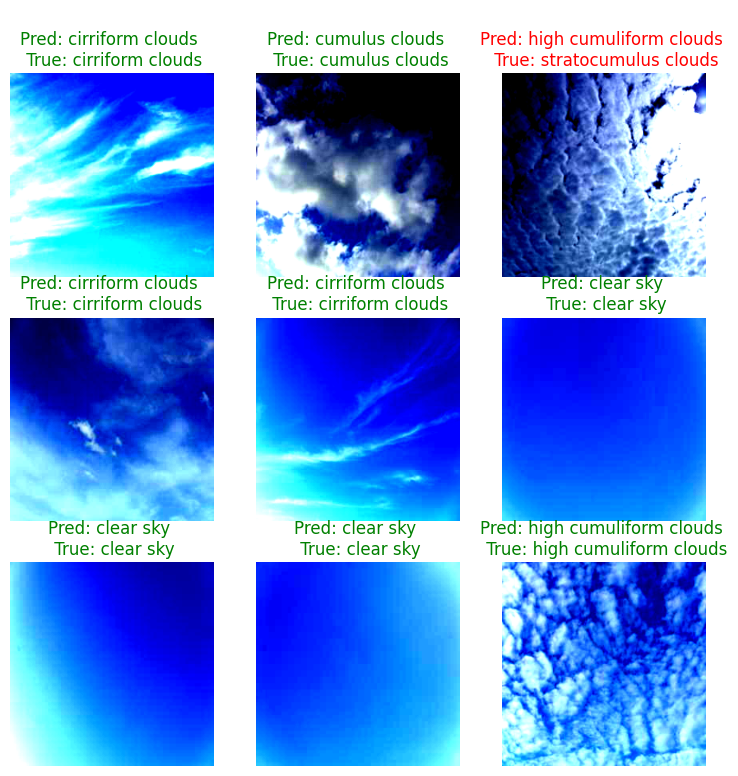

In [19]:
# Visualizing predictions
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

random_index = random.randint(0, len(test_data) - 9)


for i, sample in enumerate(test_samples[random_index : random_index + 9]):
    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.permute(1, 2, 0), cmap='grey')

    pred_label = class_names[pred_classes[i + random_index]]

    true_label = class_names[test_labels[i + random_index]]

    title_text = f'\nPred: {pred_label} \n True: {true_label}'

    plt.title(title_text, c='g' if pred_label == true_label else 'r')
    plt.axis(False)

In [20]:
# Imprimindo relatório de classificação
print(classification_report(test_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        77
           1       0.98      1.00      0.99        64
           2       0.90      0.82      0.86        11
           3       0.93      0.90      0.92       120
           4       0.87      0.87      0.87       103
           5       0.95      0.95      0.95        40
           6       0.77      0.80      0.79        71

    accuracy                           0.89       486
   macro avg       0.90      0.89      0.89       486
weighted avg       0.89      0.89      0.89       486



### Modelo com Data Augmentation


In [21]:
# Criando pipeline de data augmentation
da_data_transforms = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(45),
        transforms.RandomAutocontrast(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Importando dados de treino dos arquivos
da_train_data = ImageFolder(
    root='../datasets/clouds/clouds_train',
    transform=da_data_transforms,
)

# Importando dados de treino dos arquivos
da_test_data = ImageFolder(
    root='../datasets/clouds/clouds_test',
    transform=da_data_transforms,
)

In [22]:
# Criando DataLoader de treino
da_train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

# Criando DataLoader de teste
da_test_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

In [23]:
# Instanciando modelo
da_model = ConvNNet(
    input_channels=3,
    num_classes=len(class_to_idx),
).to(device)

In [24]:
# Função de perda
da_loss_fn = nn.CrossEntropyLoss()

# Otimizador
da_optimizer = torch.optim.Adam(
    params=da_model.parameters(),
    lr=1e-4,
)

In [25]:
# Definindo seed
torch.manual_seed(42)

# Definindo número de épocas
epochs = 100

# Definindo numero de iterações para print
print_every = epochs // 10

# Loop de treinamento
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f'Epoch: {epoch + 1}',
            '-' * 90,
            sep='\n',
            end='\n',
        )

    # Train step
    train_step(
        estimator=da_model,
        dataloader=train_dataloader,
        loss_fn=da_loss_fn,
        optimizer=da_optimizer,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

    # Test step
    test_step(
        estimator=da_model,
        loss_fn=da_loss_fn,
        dataloader=test_dataloader,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1
------------------------------------------------------------------------------------------
Train loss: 1.687 | Train accuracy: 35.11%
Test loss:  2.056 | Test accuracy:  21.74%

Epoch: 10
------------------------------------------------------------------------------------------
Train loss: 1.008 | Train accuracy: 65.14%
Test loss:  0.886 | Test accuracy:  69.53%

Epoch: 20
------------------------------------------------------------------------------------------
Train loss: 0.769 | Train accuracy: 71.81%
Test loss:  0.619 | Test accuracy:  82.03%

Epoch: 30
------------------------------------------------------------------------------------------
Train loss: 0.632 | Train accuracy: 79.29%
Test loss:  0.532 | Test accuracy:  81.77%

Epoch: 40
------------------------------------------------------------------------------------------
Train loss: 0.589 | Train accuracy: 80.59%
Test loss:  0.423 | Test accuracy:  84.11%

Epoch: 50
---------------------------------------------------

#### Fazendo previsões


In [26]:
# Creating samples and labels lists
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=len(test_data)):
    test_samples.append(sample)
    test_labels.append(label)

In [27]:
# Making predictions
pred_probs = make_predictions(estimator=da_model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3472902..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43967807..1.0539435].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4842881..1.8892884].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3815396..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55955136..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1760426..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9020

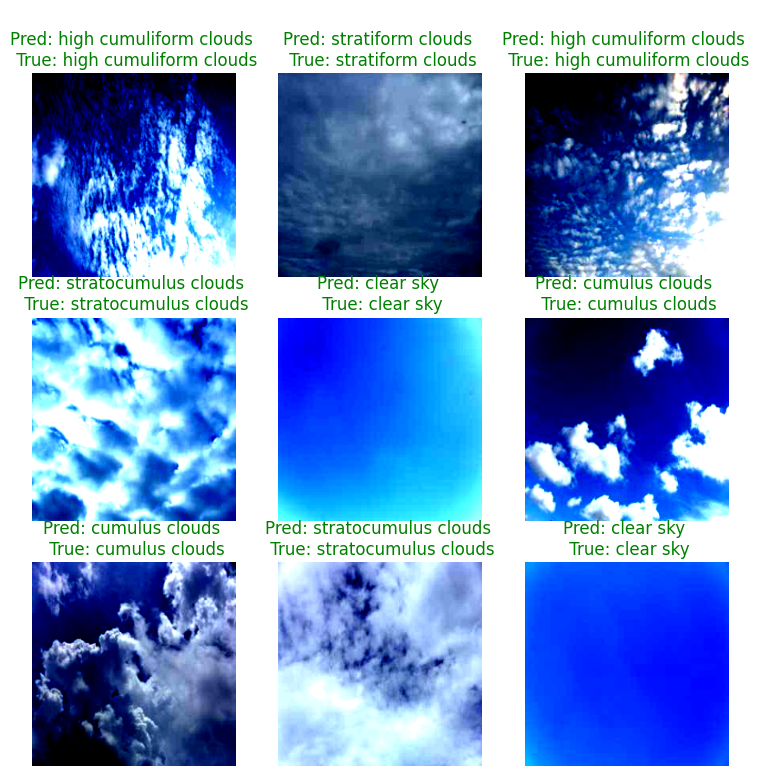

In [28]:
# Visualizing predictions
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

random_index = random.randint(0, len(test_data) - 9)


for i, sample in enumerate(test_samples[random_index : random_index + 9]):
    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.permute(1, 2, 0), cmap='grey')

    pred_label = class_names[pred_classes[i + random_index]]

    true_label = class_names[test_labels[i + random_index]]

    title_text = f'\nPred: {pred_label} \n True: {true_label}'

    plt.title(title_text, c='g' if pred_label == true_label else 'r')
    plt.axis(False)

In [29]:
# Imprimindo relatório de classificação
print(classification_report(test_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.89      0.77      0.83        77
           1       0.95      0.98      0.97        64
           2       0.67      0.91      0.77        11
           3       0.92      0.85      0.88       120
           4       0.83      0.90      0.87       103
           5       0.84      0.95      0.89        40
           6       0.79      0.79      0.79        71

    accuracy                           0.87       486
   macro avg       0.84      0.88      0.86       486
weighted avg       0.87      0.87      0.87       486



## Transfer Learning

O modelo utilizado para transfer learning foi `resnet18`, que pode ser baixado a partir da API to `torchvision`. Esse modelo é uma _CNN_ com 18 camadas, que possui implementação da técnica de **_residuals_**. Essa técnica intende diminuir o problema do gradiente desaparecendo, onde os gradientes usados para o treinamento do modelo se tornam muito pequenos ou "_desaparecem_", a medida que o algoritmo de _backpropagation_ passa das camadas mais à superficie, para as mais profundas. Os residuals mitigam esse problema, ao introduzir um "_curto-circuito_" entre as camadas, por onde o gradiente pode "passar" para as camadas mais profundas, com menor diminuição.

Os pesos usados foram os "_`IMAGENET1K_V1`_", que obteve acc@1 (acurácia top-1) de $69.758$% no dataset _ImageNet-1K_.

### Performance na classificação de Nuvens

A performance do modelo em classificação de nuvens foi altíssima, com acurácia de ~$92$% nos dados de teste, com apenas $20$ épocas de treinamento. Esse resultado demonstra a alta capacidade dos modelos de _transfer learning_ de se adaptar a diferentes problemas, especialmente em problemas de visão computacional.


In [30]:
# Criando transformadores de imagens
tl_data_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Criando datasets a partir de arquivos
tl_train_data = ImageFolder(
    '../datasets/clouds/clouds_train',
    transform=data_transforms,
)
tl_test_data = ImageFolder(
    '../datasets/clouds/clouds_test',
    transform=data_transforms,
)

# Criando dataloaders de treino e teste
tl_train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
)
tl_test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
)

In [ ]:
# Instanciando modelo
tl_model = models.resnet18(weights='IMAGENET1K_V1').to(device)

# Desativando camadas de feature extraction
for param in tl_model.parameters():
    param.requires_grad = False

# Ativando camadas de classificação
for param in tl_model.layer4.parameters():
    param.requires_grad = True

# Adicionando "head" ao modelo
tl_model.fc = nn.Linear(tl_model.fc.in_features, len(class_names))

In [ ]:
# Definindo função de perda
tl_loss_fn = nn.CrossEntropyLoss()

# Definindo otimizador
tl_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-4,
)

In [33]:
# Definindo seed
torch.manual_seed(42)

# Definindo número de épocas
epochs = 20

# Definindo numero de iterações para print
print_every = epochs // 10

# Loop de treinamento
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f'Epoch: {epoch + 1}',
            '-' * 90,
            sep='\n',
            end='\n',
        )

    # Train step
    train_step(
        estimator=tl_model,
        dataloader=tl_train_loader,
        loss_fn=tl_loss_fn,
        optimizer=tl_optimizer,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

    # Test step
    test_step(
        estimator=tl_model,
        loss_fn=tl_loss_fn,
        dataloader=tl_test_loader,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1
------------------------------------------------------------------------------------------
Train loss: 1.289 | Train accuracy: 59.70%
Test loss:  0.646 | Test accuracy:  83.85%

Epoch: 2
------------------------------------------------------------------------------------------
Train loss: 0.251 | Train accuracy: 95.58%
Test loss:  0.325 | Test accuracy:  89.13%

Epoch: 4
------------------------------------------------------------------------------------------
Train loss: 0.053 | Train accuracy: 99.79%
Test loss:  0.227 | Test accuracy:  91.15%

Epoch: 6
------------------------------------------------------------------------------------------
Train loss: 0.025 | Train accuracy: 100.00%
Test loss:  0.214 | Test accuracy:  91.54%

Epoch: 8
------------------------------------------------------------------------------------------
Train loss: 0.024 | Train accuracy: 100.00%
Test loss:  0.211 | Test accuracy:  91.73%

Epoch: 10
-----------------------------------------------------

### Fazendo previsões


In [34]:
# Creating samples and labels lists
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=len(test_data)):
    test_samples.append(sample)
    test_labels.append(label)

In [35]:
# Making predictions
pred_probs = make_predictions(estimator=da_model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2616663..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2102921..1.6988237].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2274169..1.7162529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9705454..1.8033988].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55955136..0.8622224].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.19316

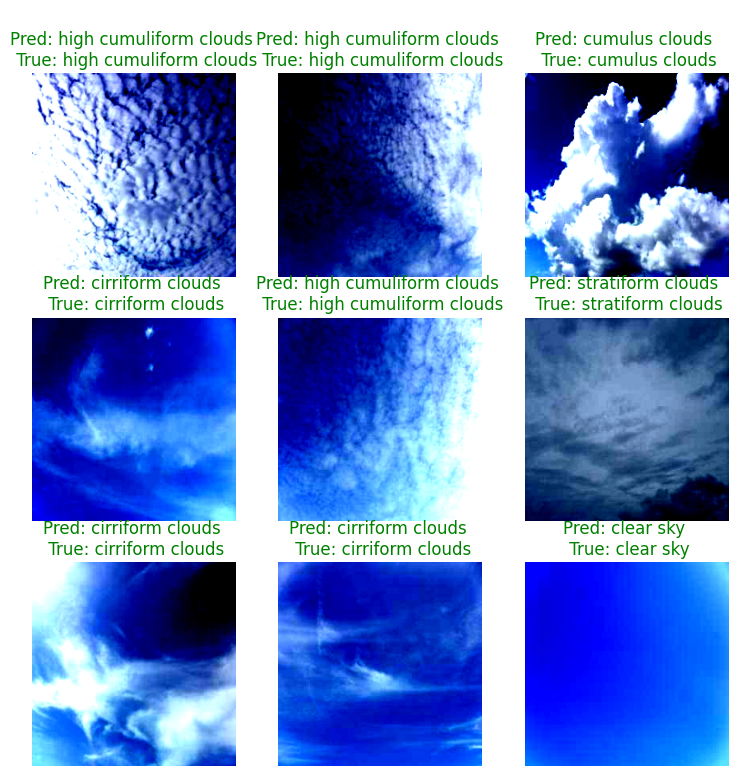

In [36]:
# Visualizing predictions
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

random_index = random.randint(0, len(test_data) - 9)


for i, sample in enumerate(test_samples[random_index : random_index + 9]):
    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.permute(1, 2, 0), cmap='grey')

    pred_label = class_names[pred_classes[i + random_index]]

    true_label = class_names[test_labels[i + random_index]]

    title_text = f'\nPred: {pred_label} \n True: {true_label}'

    plt.title(title_text, c='g' if pred_label == true_label else 'r')
    plt.axis(False)

In [37]:
# Imprimindo relatório de classificação
print(classification_report(test_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.89      0.77      0.83        77
           1       0.95      0.98      0.97        64
           2       0.67      0.91      0.77        11
           3       0.92      0.85      0.88       120
           4       0.83      0.90      0.87       103
           5       0.84      0.95      0.89        40
           6       0.79      0.79      0.79        71

    accuracy                           0.87       486
   macro avg       0.84      0.88      0.86       486
weighted avg       0.87      0.87      0.87       486

